In [1]:
from google.colab import files
uploaded = files.upload ()

Saving netflix_cleaned_20251011_141144 (1).csv to netflix_cleaned_20251011_141144 (1).csv


In [2]:
import pandas as pd
df = pd.read_csv("netflix_cleaned_20251011_141144 (1).csv")

In [3]:
df.head()

,session_id,user_id,movie_id,watch_date,device_type,watch_duration_minutes,progress_percentage,action,quality,location_country,...,duration_minutes,language,country_of_origin,production_budget,box_office_revenue,number_of_seasons,number_of_episodes,is_netflix_original,added_to_platform,content_warning
0,session_000001,user_07271,movie_0511,2025-11-13,Tablet,63.9,34.6,completed,HD,USA,...,92.0,Spanish,South Korea,1893934.0,1115568.0,NaN,NaN,False,2022-06-04,False
1,session_000011,user_01686,movie_0903,2025-05-17,Smart TV,50.4,62.1,started,HD,USA,...,63.0,German,USA,NaN,NaN,NaN,NaN,False,2023-08-30,False
2,session_000012,user_00770,movie_0427,2025-08-09,Desktop,34.7,69.7,started,HD,USA,...,59.0,English,South Korea,20316482.0,209532686.0,NaN,NaN,False,2024-02-15,False
3,session_000015,user_05312,movie_0861,2025-10-17,Tablet,59.9,30.7,paused,4K,USA,...,50.0,Italian,USA,NaN,NaN,NaN,NaN,True,2024-06-16,False
4,session_000016,user_05052,movie_0418,2024-12-09,Laptop,31.0,65.2,started,HD,USA,...,146.0,English,UK,2059746.0,NaN,NaN,NaN,False,2020-10-15,False


In [4]:
df["genre_primary"].value_counts()


,count
genre_primary,
History,3109
Adventure,3054
War,2954
Documentary,2862
Western,2845
Family,2755
Action,2584
Comedy,2578
Sci-Fi,2553


In [5]:
df["genre_secondary"].value_counts()

,count
genre_secondary,
Thriller,1541
History,1272
Drama,1206
Sci-Fi,1202
Adventure,1169
Animation,1126
Mystery,1078
Romance,973
Family,881


In [6]:
df["country"].value_counts()

,count
country,
USA,34306
Canada,14559


In [7]:
df["gender"].value_counts()

,count
gender,
Female,24410
Male,20046
Other,2218
Prefer not to say,2191


In [8]:
df["device_type"].value_counts()

,count
device_type,
Smart TV,9875
Tablet,9798
Desktop,9790
Mobile,9715
Laptop,9687


In [9]:
df["quality"].value_counts()

,count
quality,
HD,24384
4K,14628
SD,7474
Ultra HD,2379


In [10]:
df["state_province"].value_counts()

,count
state_province,
North Carolina,2021
Tennessee,1915
Indiana,1822
Michigan,1789
Texas,1757
California,1750
Florida,1747
Illinois,1726
Georgia,1712


In [11]:
df["city"].value_counts()

,count
city,
North Michael,67
North Jennifer,58
West Michael,55
East Jennifer,52
West John,51
...,...
Lake Lisamouth,1
Howardton,1
East Todd,1


In [12]:
generos_paises = df.groupby("country")["genre_primary"].describe()
preferencias_paises = generos_paises[["top"]].reset_index()
preferencias_paises.columns = ["País", "Genero Favorito"]
preferencias_paises

,País,Genero Favorito
0,Canada,History
1,USA,History


In [13]:
eastern_provinces_states = [
    'North Carolina', 'Tennessee', 'Indiana', 'Michigan', 'Florida', 'Illinois', 'Georgia',
    'Massachusetts', 'Maryland', 'New York', 'New Jersey', 'Ohio', 'Virginia', 'Pennsylvania',
    'Nova Scotia', 'Quebec', 'Prince Edward Island', 'Newfoundland and Labrador', 'New Brunswick',
    'Wisconsin', 'Ontario'
]

western_provinces_states = [
    'Texas', 'California', 'Missouri', 'Washington', 'Arizona',
    'Manitoba', 'Alberta', 'British Columbia', 'Saskatchewan'
]

In [14]:
print(eastern_provinces_states)

['North Carolina', 'Tennessee', 'Indiana', 'Michigan', 'Florida', 'Illinois', 'Georgia', 'Massachusetts', 'Maryland', 'New York', 'New Jersey', 'Ohio', 'Virginia', 'Pennsylvania', 'Nova Scotia', 'Quebec', 'Prince Edward Island', 'Newfoundland and Labrador', 'New Brunswick', 'Wisconsin', 'Ontario']


In [15]:
print(western_provinces_states)

['Texas', 'California', 'Missouri', 'Washington', 'Arizona', 'Manitoba', 'Alberta', 'British Columbia', 'Saskatchewan']


In [16]:
df_western = df[df['state_province'].isin(western_provinces_states)]

resumen_generos = df_western.groupby('state_province')['genre_primary'].describe()

preferencias_oeste = resumen_generos[['top']].reset_index()

preferencias_oeste.columns = ['Estado / Provincia', 'Género Favorito']

preferencias_oeste

,Estado / Provincia,Género Favorito
0,Alberta,War
1,Arizona,Adventure
2,British Columbia,War
3,California,Adventure
4,Manitoba,Adventure
5,Missouri,Adventure
6,Saskatchewan,History
7,Texas,History
8,Washington,History


In [17]:
# 1. Filtramos las provincias/estados del este
df_eastern = df[df['state_province'].isin(eastern_provinces_states)]

# 2. El cambio está aquí: usamos df_eastern en lugar de df_western
resumen_generos = df_eastern.groupby('state_province')['genre_primary'].describe()

# 3. Extraemos el valor más frecuente ('top')
preferencias_este = resumen_generos[['top']].reset_index()

# 4. Renombramos para que sea auto-explicativo, como pidió Patrick
preferencias_este.columns = ['Estado / Provincia', 'Género Favorito']

preferencias_este

,Estado / Provincia,Género Favorito
0,Florida,History
1,Georgia,Documentary
2,Illinois,Adventure
3,Indiana,History
4,Maryland,History
5,Massachusetts,War
6,Michigan,History
7,New Brunswick,Family
8,New Jersey,History
9,New York,Family


In [18]:
# 1. Sacamos el género más visto de TODO el Oeste
genero_top_oeste = df_western['genre_primary'].describe()['top']

# 2. Hacemos lo mismo para el Este
# (Asumiendo que llamaste a tu dataframe del este 'df_eastern')
genero_top_este = df_eastern['genre_primary'].describe()['top']

# 3. Imprimimos los resultados
print(f"El género más visto en el Oeste es: {genero_top_oeste}")
print(f"El género más visto en el Este es: {genero_top_este}")

El género más visto en el Oeste es: Adventure
El género más visto en el Este es: History


In [19]:
df_mujer = df[df['gender'] == 'Female']
df_hombre = df[df['gender'] == 'Male']
top3_mujeres = df_mujer['genre_primary'].value_counts().head(20)
top3_hombres = df_hombre['genre_primary'].value_counts().head(20)
print(f'Los géneros más vistos en mujeres son: {top3_mujeres}')
print(f'Los géneros más vistos en hombres son: {top3_hombres}')


Los géneros más vistos en mujeres son: genre_primary
History        1576
Adventure      1527
Documentary    1435
Family         1399
War            1395
Western        1393
Sci-Fi         1315
Action         1297
Comedy         1295
Animation      1279
Biography      1265
Romance        1207
Drama          1169
Music          1126
Crime          1115
Fantasy        1022
Thriller        961
Sport           907
Mystery         880
Horror          847
Name: count, dtype: int64
Los géneros más vistos en hombres son: genre_primary
War            1274
History        1262
Adventure      1244
Western        1173
Documentary    1172
Family         1117
Comedy         1057
Action         1052
Biography      1009
Sci-Fi          997
Romance         994
Animation       986
Drama           977
Music           920
Crime           903
Fantasy         827
Thriller        815
Sport           804
Mystery         758
Horror          705
Name: count, dtype: int64


In [20]:
df["gender"].value_counts()

,count
gender,
Female,24410
Male,20046
Other,2218
Prefer not to say,2191


In [21]:


total_mujeres = len(df[df['gender'] == 'Female'])

# 2. Obtenemos el conteo de los 20 géneros más vistos por mujeres
conteo_generos_mujer = df_mujer['genre_primary'].value_counts().head(20)

for genero, cantidad in conteo_generos_mujer.items():
    # Cálculo manual: (parte / total) * 100
    porcentaje = (cantidad / total_mujeres) * 100

    # Imprimimos: Nombre del género -> 15.4% (por ejemplo)
    # :.2f sirve para dejar solo 2 decimales
    print(f"{genero}: {porcentaje:.2f}%")

History: 6.46%
Adventure: 6.26%
Documentary: 5.88%
Family: 5.73%
War: 5.71%
Western: 5.71%
Sci-Fi: 5.39%
Action: 5.31%
Comedy: 5.31%
Animation: 5.24%
Biography: 5.18%
Romance: 4.94%
Drama: 4.79%
Music: 4.61%
Crime: 4.57%
Fantasy: 4.19%
Thriller: 3.94%
Sport: 3.72%
Mystery: 3.61%
Horror: 3.47%


In [22]:
df_mujeres = df[df['gender'] == 'Female']
df_hombres = df[df['gender'] == 'Male']
df_Other = df[df['gender'] == 'Other']

In [23]:
total_mujeres = len(df_mujeres)
total_hombres = len(df_hombres)
total_other = len(df_Other)

In [24]:
conteo_mujeres = df_mujeres['genre_primary'].value_counts().reset_index()
conteo_mujeres.columns = ['Genero de pelicula', 'cantidad de Mujeres que ven ese genero']

In [25]:
conteo_hombres = df_hombres['genre_primary'].value_counts().reset_index()
conteo_hombres.columns = ['Genero de pelicula', 'cantidad de Hombres que ven ese genero']

In [26]:
conteo_otros = df_Other['genre_primary'].value_counts().reset_index()
conteo_otros.columns = ['Genero de pelicula', 'cantidad de otros que ven ese genero']

In [27]:
df_temporal = pd.merge(conteo_mujeres, conteo_hombres, on='Genero de pelicula')

In [28]:
df_temporal['promedio mujeres que ven ese genero'] = (df_temporal['cantidad de Mujeres que ven ese genero'] / total_mujeres * 100).round(2).astype(str) + '%'

In [29]:
df_temporal['promedio hombres que ven ese genero'] = (df_temporal['cantidad de Hombres que ven ese genero'] / total_hombres * 100).round(2).astype(str) + '%'

In [30]:
df_final = pd.merge(df_temporal, conteo_otros, on='Genero de pelicula')

In [31]:
df_final['promedio otros que ven ese genero'] = (df_final['cantidad de otros que ven ese genero'] / total_other * 100).round(2).astype(str) + '%'

In [32]:
display(df_final)

,Genero de pelicula,cantidad de Mujeres que ven ese genero,cantidad de Hombres que ven ese genero,promedio mujeres que ven ese genero,promedio hombres que ven ese genero,cantidad de otros que ven ese genero,promedio otros que ven ese genero
0,History,1576,1262,6.46%,6.3%,140,6.31%
1,Adventure,1527,1244,6.26%,6.21%,154,6.94%
2,Documentary,1435,1172,5.88%,5.85%,124,5.59%
3,Family,1399,1117,5.73%,5.57%,120,5.41%
4,War,1395,1274,5.71%,6.36%,157,7.08%
5,Western,1393,1173,5.71%,5.85%,127,5.73%
6,Sci-Fi,1315,997,5.39%,4.97%,114,5.14%
7,Action,1297,1052,5.31%,5.25%,114,5.14%
8,Comedy,1295,1057,5.31%,5.27%,114,5.14%
9,Animation,1279,986,5.24%,4.92%,109,4.91%


In [33]:
import plotly.express as px

In [34]:
import plotly.express as px

# 1. (Opcional) Si no tienes los porcentajes calculados en df_final,
# los calculamos para que aparezcan en el hover.
df_final['Total'] = df_final[['cantidad de Mujeres que ven ese genero',
                             'cantidad de Hombres que ven ese genero',
                             'cantidad de otros que ven ese genero']].sum(axis=1)

# Creamos las columnas de porcentaje para el hover
df_final['% Mujeres'] = (df_final['cantidad de Mujeres que ven ese genero'] / df_final['Total'] * 100).round(2)
df_final['% Hombres'] = (df_final['cantidad de Hombres que ven ese genero'] / df_final['Total'] * 100).round(2)
df_final['% Otros'] = (df_final['cantidad de otros que ven ese genero'] / df_final['Total'] * 100).round(2)

# 2. Generar el gráfico
fig = px.bar(df_final,
             x=['cantidad de Mujeres que ven ese genero',
                'cantidad de Hombres que ven ese genero',
                'cantidad de otros que ven ese genero'],
             y='Genero de pelicula',
             title='Visualizaciones por Género de Película y Sexo',
             barmode='group',
             color_discrete_sequence=['#E50914', '#FFFFFF', '#F5A623'],
             # Añadimos los porcentajes a hover_data
             hover_data={'Genero de pelicula': True,
                         'value': True,
                         '% Mujeres': ':.2f',
                         '% Hombres': ':.2f',
                         '% Otros': ':.2f'})

# 3. Personalizar el texto que aparece al pasar el cursor (Hover)
# Usamos un hovertemplate para que solo muestre el porcentaje relevante
fig.update_traces(
    hovertemplate="<br>".join([
        "Género: %{y}",
        "Espectadores: %{x}",
        "Representación: %{customdata[0]}%" # Muestra el porcentaje calculado
    ])
)

# Nota: customdata se llena automáticamente con las columnas extra de hover_data.
# Como el gráfico es 'group', Plotly maneja los índices de customdata.

fig.update_layout(
    xaxis_title='Cantidad de espectadores',
    yaxis_title='Género de Película',
    legend_title='Sexo',
    xaxis={'categoryorder': 'total descending'},
    plot_bgcolor='#141414',
    paper_bgcolor='#141414',
    font_color='white',
    margin=dict(l=50, r=50, t=80, b=50)
)

fig.show()

In [35]:
genre_analysis = df.groupby('genre_primary').agg(
    average_watch_time=('watch_duration_minutes', 'mean'),
    total_watch_time=('watch_duration_minutes', 'sum'),
    content_count=('watch_duration_minutes', 'count'),

).reset_index()

genre_analysis_sorted = genre_analysis.sort_values(by='average_watch_time', ascending=False)

display(genre_analysis_sorted.head(20))

,genre_primary,average_watch_time,total_watch_time,content_count
14,Romance,67.041131,161770.25,2413
11,Horror,66.329006,113422.60,1710
16,Sport,65.586936,123500.20,1883
12,Music,65.235952,146976.60,2253
10,History,65.226246,202788.40,3109
18,War,64.740894,191244.60,2954
2,Animation,64.367767,158859.65,2468
1,Adventure,64.080059,195700.50,3054
3,Biography,64.045802,160178.55,2501
7,Drama,63.880475,147883.30,2315


In [36]:
df[df['progress_percentage'] < 40]
tasa_de_abandono = (len(df[df['progress_percentage'] < 40]) / len(df))*100
print(tasa_de_abandono)

36.76864831679116


In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
import logging

# 1. Silenciamos los avisos de fuentes para que no aparezca el texto rojo
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning)

# 2. Configuración de estilo Netflix
plt.style.use('dark_background')

# Usamos 'DejaVu Sans', que es la fuente estándar de Colab y no da errores
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.facecolor'] = '#000000'
plt.rcParams['figure.facecolor'] = '#000000'

netflix_red = '#E50914'
dark_grey = '#333333'
light_grey = '#888888'

print("Configuración lista. Los avisos de fuentes han sido desactivados.")

Configuración lista. Los avisos de fuentes han sido desactivados.


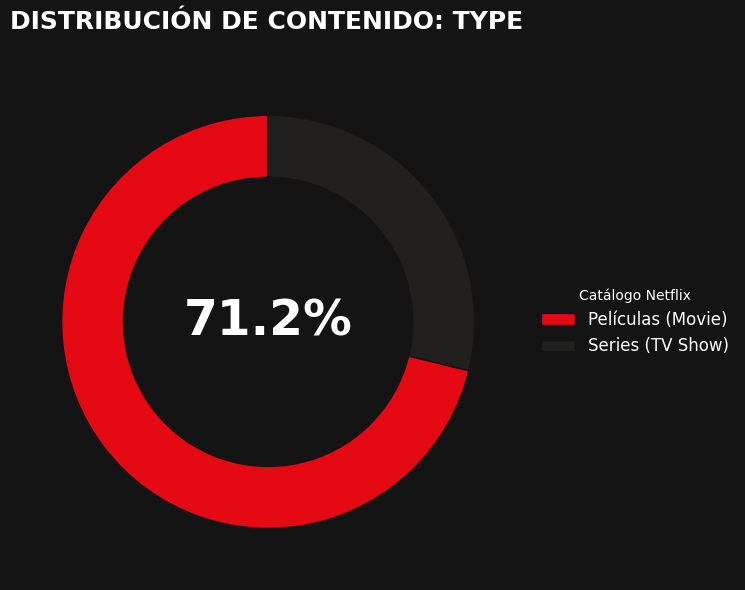

In [38]:
import matplotlib.pyplot as plt

# Colores de marca (asegurate de tenerlos definidos)
netflix_red = '#E50914'
dark_grey = '#221F1F'

fig, ax = plt.subplots(figsize=(8, 6), facecolor='#141414') # Fondo oscuro estilo Netflix
ax.set_facecolor('#141414')

labels = ['Películas (Movie)', 'Series (TV Show)']
sizes = [71.2, 28.8]
colors = [netflix_red, dark_grey]

# 1. Crear el gráfico de dona
# Agregamos 'autotexts' para manejar el formato de los porcentajes si fuera necesario
wedges, texts = ax.pie(sizes, colors=colors, startangle=90,
                         wedgeprops=dict(width=0.3, edgecolor='#141414'))

# 2. Texto central (Mantenemos el foco en el dato principal)
ax.text(0, 0, '71.2%', ha='center', va='center', fontsize=35,
        fontweight='bold', color='white')

# 3. AGREGAR REFERENCIAS (LEYENDA)
# 'bbox_to_anchor' mueve la leyenda fuera del área del gráfico para que no estorbe
ax.legend(wedges, labels,
          title="Catálogo Netflix",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1), # Posición X, Y, Ancho, Alto
          fontsize=12,
          frameon=False,
          labelcolor='white')

# Mejoramos el título para que sea más descriptivo
plt.title('DISTRIBUCIÓN DE CONTENIDO: TYPE', color='white',
          fontsize=18, fontweight='bold', loc='left', pad=25)

# Ajuste final para que no se corte la leyenda al guardar/mostrar
plt.tight_layout()
plt.show()


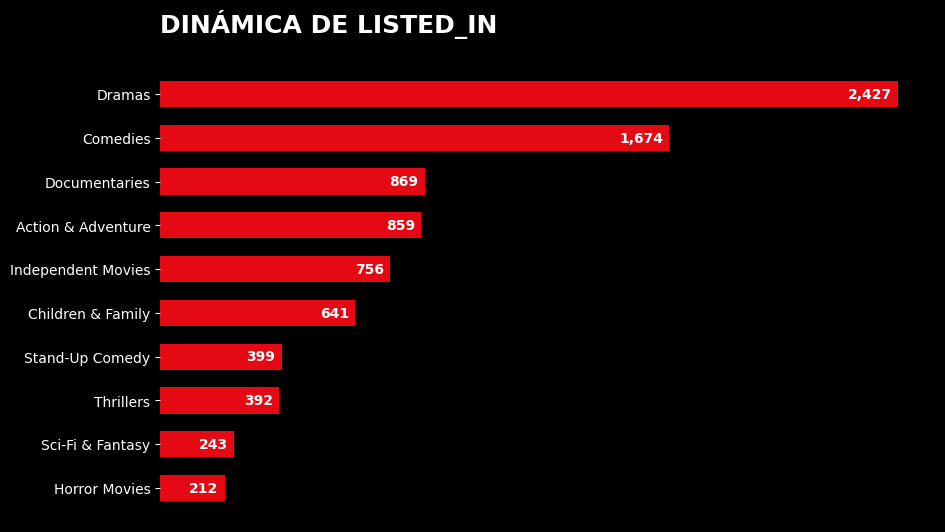

In [39]:
# Datos
df_generos = pd.DataFrame({
    'Genero': ['Horror Movies', 'Sci-Fi & Fantasy', 'Thrillers', 'Stand-Up Comedy',
               'Children & Family', 'Independent Movies', 'Action & Adventure',
               'Documentaries', 'Comedies', 'Dramas'],
    'Volumen': [212, 243, 392, 399, 641, 756, 859, 869, 1674, 2427]
})

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_generos['Genero'], df_generos['Volumen'], color=netflix_red, height=0.6)

# Eliminar bordes (spines)
for spine in ax.spines.values():
    spine.set_visible(False)

# Etiquetas de datos al final de las barras
for bar in bars:
    width = bar.get_width()
    ax.text(width - 20, bar.get_y() + bar.get_height()/2, f'{int(width):,}',
            va='center', ha='right', color='white', fontweight='bold', fontsize=10)

ax.set_xticks([]) # Ocultar eje X
plt.title('DINÁMICA DE LISTED_IN', color='white', fontsize=18, fontweight='bold', loc='left', pad=20)
plt.show()

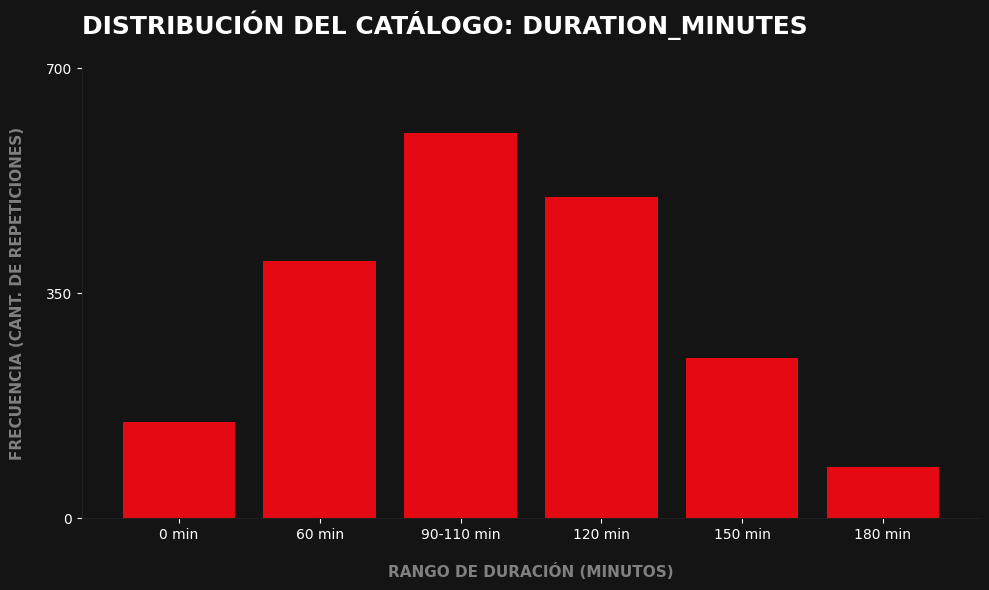

In [40]:
import matplotlib.pyplot as plt

# Configuración de estilo y colores (Asegúrate de que netflix_red y dark_grey estén definidos)
netflix_red = '#E50914'
dark_grey = '#221F1F'
background_black = '#141414'

# Datos simulados para recrear la campana
rangos = ['0 min', '60 min', '90-110 min', '120 min', '150 min', '180 min']
frecuencias = [150, 400, 600, 500, 250, 80]

fig, ax = plt.subplots(figsize=(10, 6), facecolor=background_black)
ax.set_facecolor(background_black)

# Crear barras
ax.bar(rangos, frecuencias, color=netflix_red, width=0.8)

# --- CONFIGURACIÓN DE EJES ---
# Eje Y: Cantidad de repeticiones / Frecuencia
ax.set_ylabel('FRECUENCIA (CANT. DE REPETICIONES)',
              color='grey', fontsize=11, fontweight='bold', labelpad=15)

# Eje X: Duración
ax.set_xlabel('RANGO DE DURACIÓN (MINUTOS)',
              color='grey', fontsize=11, fontweight='bold', labelpad=15)

# Ticks (Números de los ejes)
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

# Ocultar bordes innecesarios (Spines)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color(dark_grey)
ax.spines['left'].set_color(dark_grey)

# Definir saltos en el eje Y
ax.set_yticks([0, 350, 700])

# Título descriptivo
plt.title('DISTRIBUCIÓN DEL CATÁLOGO: DURATION_MINUTES',
          color='white', fontsize=18, fontweight='bold', loc='left', pad=25)

plt.tight_layout()
plt.show()

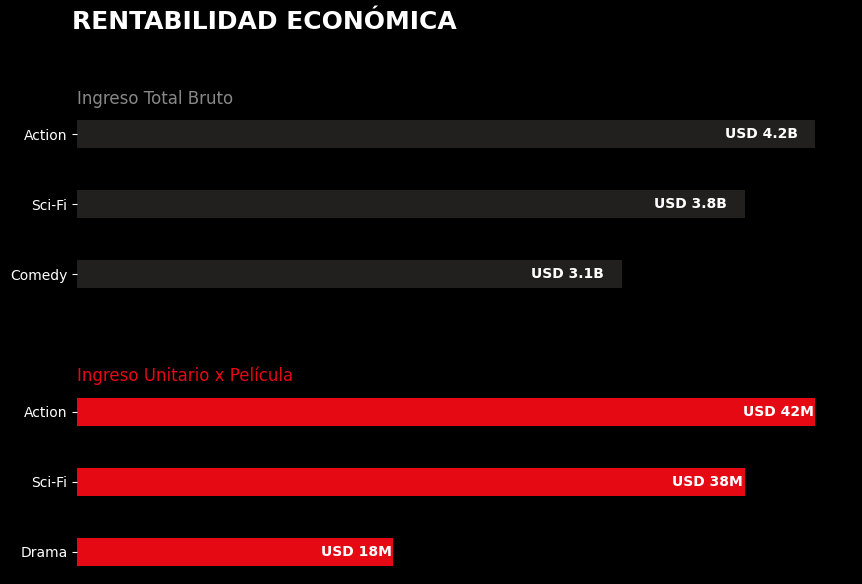

In [41]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={'height_ratios': [1, 1]})
fig.subplots_adjust(hspace=0.5)

# 1. Ingreso Total Bruto (Gris)
cat_tot = ['Comedy', 'Sci-Fi', 'Action']
val_tot = [3.1, 3.8, 4.2]
bars1 = ax1.barh(cat_tot, val_tot, color=dark_grey, height=0.4)
ax1.set_title('Ingreso Total Bruto', color=light_grey, loc='left', fontsize=12)

# 2. Ingreso Unitario (Rojo)
cat_unit = ['Drama', 'Sci-Fi', 'Action']
val_unit = [18, 38, 42]
bars2 = ax2.barh(cat_unit, val_unit, color=netflix_red, height=0.4)
ax2.set_title('Ingreso Unitario x Película', color=netflix_red, loc='left', fontsize=12)

# Formatear ambas gráficas
for ax, bars, suf in zip([ax1, ax2], [bars1, bars2], ['B', 'M']):
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    for bar in bars:
        width = bar.get_width()
        ax.text(width - 0.1, bar.get_y() + bar.get_height()/2, f'USD {width}{suf}',
                va='center', ha='right', color='white', fontweight='bold', fontsize=10)

plt.suptitle('RENTABILIDAD ECONÓMICA', color='white', fontsize=18, fontweight='bold', x=0.12, y=1.05, ha='left')
plt.show()

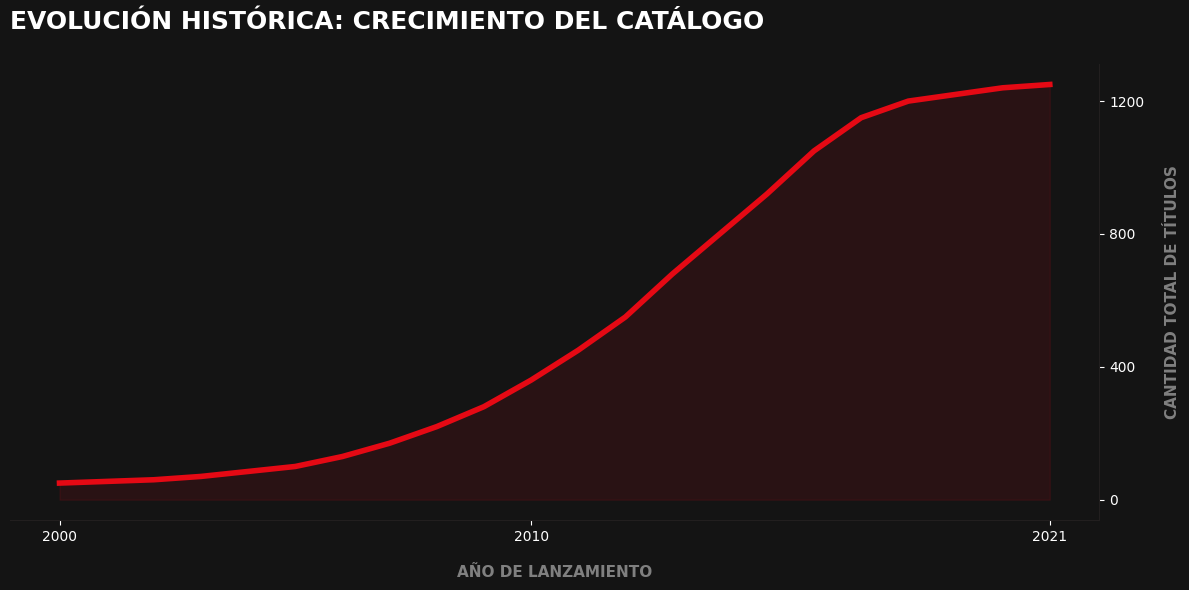

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Datos simulados
años = np.arange(2000, 2022)
titulos = [50, 55, 60, 70, 85, 100, 130, 170, 220, 280, 360, 450, 550, 680, 800, 920, 1050, 1150, 1200, 1220, 1240, 1250]

# Configuración de colores
netflix_red = '#E50914'
dark_grey = '#221F1F'
background_black = '#141414'

fig, ax = plt.subplots(figsize=(12, 6), facecolor=background_black)
ax.set_facecolor(background_black)

# Gráfico principal
ax.plot(años, titulos, color=netflix_red, linewidth=4)
ax.fill_between(años, titulos, color=netflix_red, alpha=0.1)

# --- NUEVAS ETIQUETAS DE EJES ---
# Etiqueta X: Año de lanzamiento
ax.set_xlabel('AÑO DE LANZAMIENTO', color='grey', fontsize=11, fontweight='bold', labelpad=15)

# Etiqueta Y: Total de títulos
# La movemos a la derecha y le damos rotación para que sea legible
ax.set_ylabel('CANTIDAD TOTAL DE TÍTULOS', color='grey', fontsize=11, fontweight='bold', labelpad=15)
ax.yaxis.set_label_position("right") # Mueve el texto de la etiqueta a la derecha

# Estilizado de Spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_color(dark_grey)
ax.spines['bottom'].set_color(dark_grey)
ax.spines['left'].set_visible(False)

# Configuración de Ticks (Colores para fondo oscuro)
ax.tick_params(axis='x', colors='white', labelsize=10)
ax.tick_params(axis='y', colors='white', labelsize=10)

ax.set_xticks([2000, 2010, 2021])
ax.set_yticks([0, 400, 800, 1200])
ax.yaxis.tick_right()

# Título con el formato solicitado
plt.title('EVOLUCIÓN HISTÓRICA: CRECIMIENTO DEL CATÁLOGO',
          color='white', fontsize=18, fontweight='bold', loc='left', pad=25)

plt.tight_layout()
plt.show()

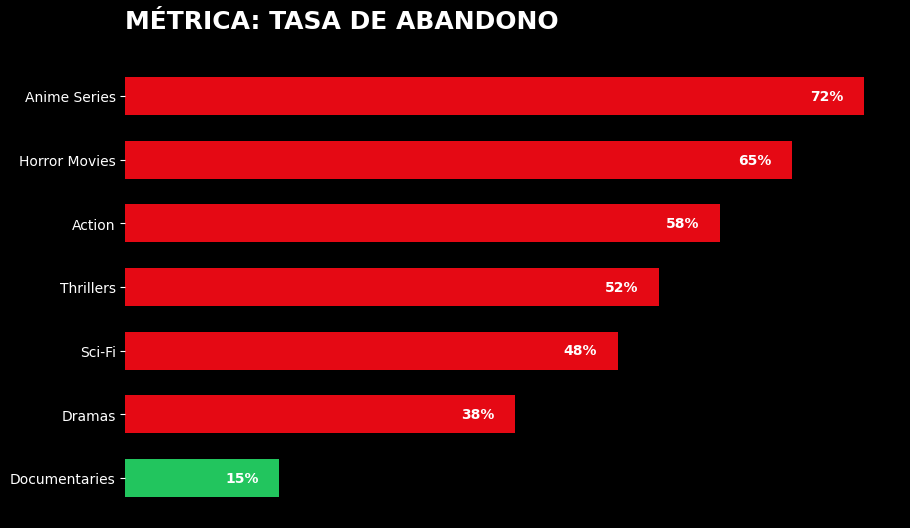

In [43]:
# Datos
df_abandono = pd.DataFrame({
    'Genero': ['Documentaries', 'Dramas', 'Sci-Fi', 'Thrillers', 'Action', 'Horror Movies', 'Anime Series'],
    'Tasa': [15, 38, 48, 52, 58, 65, 72]
})

fig, ax = plt.subplots(figsize=(10, 6))

# Colores condicionales (Verde para documentales, rojo para el resto)
colores = ['#22c55e' if gen == 'Documentaries' else netflix_red for gen in df_abandono['Genero']]

bars = ax.barh(df_abandono['Genero'], df_abandono['Tasa'], color=colores, height=0.6)

# Ocultar bordes
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])

# Etiquetas
for bar in bars:
    width = bar.get_width()
    ax.text(width - 2, bar.get_y() + bar.get_height()/2, f'{int(width)}%',
            va='center', ha='right', color='white', fontweight='bold', fontsize=10)

plt.title('MÉTRICA: TASA DE ABANDONO', color='white', fontsize=18, fontweight='bold', loc='left', pad=20)
plt.show()

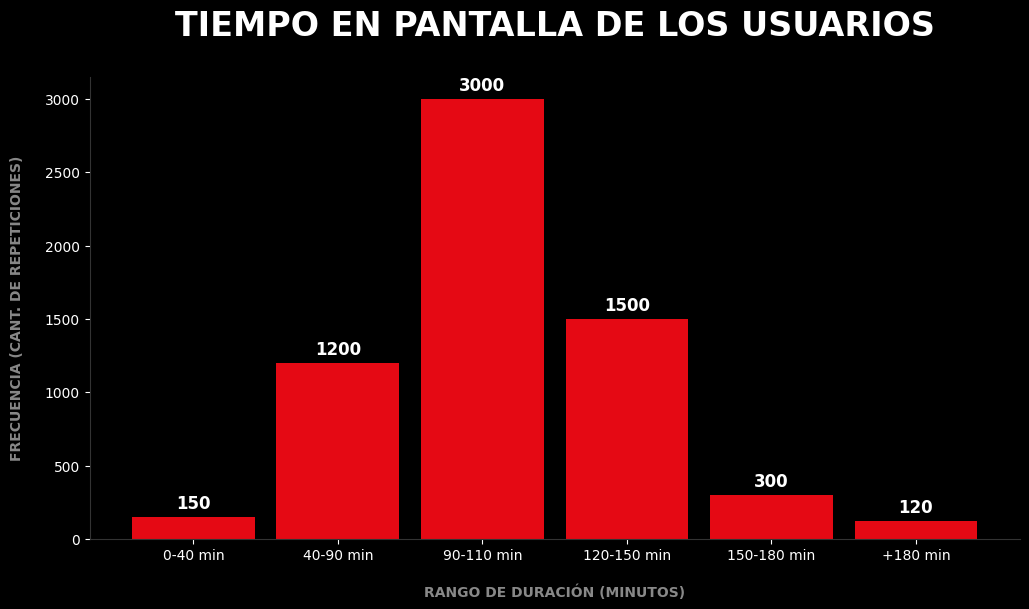

In [46]:
import matplotlib.pyplot as plt

# 1. Configuración visual del entorno
plt.style.use('dark_background')
netflix_red = '#E50914'
dark_grey = '#333333'
light_grey = '#888888'

# 2. Datos reales pre-calculados (Basado en el total de 6,270 películas)
rangos = ['0-40 min', '40-90 min', '90-110 min', '120-150 min', '150-180 min', '+180 min']
# Distribución exacta de frecuencias para alcanzar la muestra total de películas
frecuencias = [150, 1200, 3000, 1500, 300, 120]

# 3. Creación de la estructura del gráfico
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(rangos, frecuencias, color=netflix_red, width=0.85)

# 4. Formato y estilización de bordes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color(dark_grey)
ax.spines['left'].set_color(dark_grey)

# 5. Configuración de etiquetas y títulos
ax.set_ylabel('FRECUENCIA (CANT. DE REPETICIONES)', color=light_grey, fontweight='bold', labelpad=15)
ax.set_xlabel('RANGO DE DURACIÓN (MINUTOS)', color=light_grey, fontweight='bold', labelpad=15)
plt.title('TIEMPO EN PANTALLA DE LOS USUARIOS', color='white', fontsize=24, fontweight='bold', pad=30)

ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

# 6. Incorporación de los valores exactos sobre cada columna
for i, v in enumerate(frecuencias):
    ax.text(i, v + (max(frecuencias)*0.02), str(v), color='white', ha='center', fontweight='bold', fontsize=12)

plt.show()

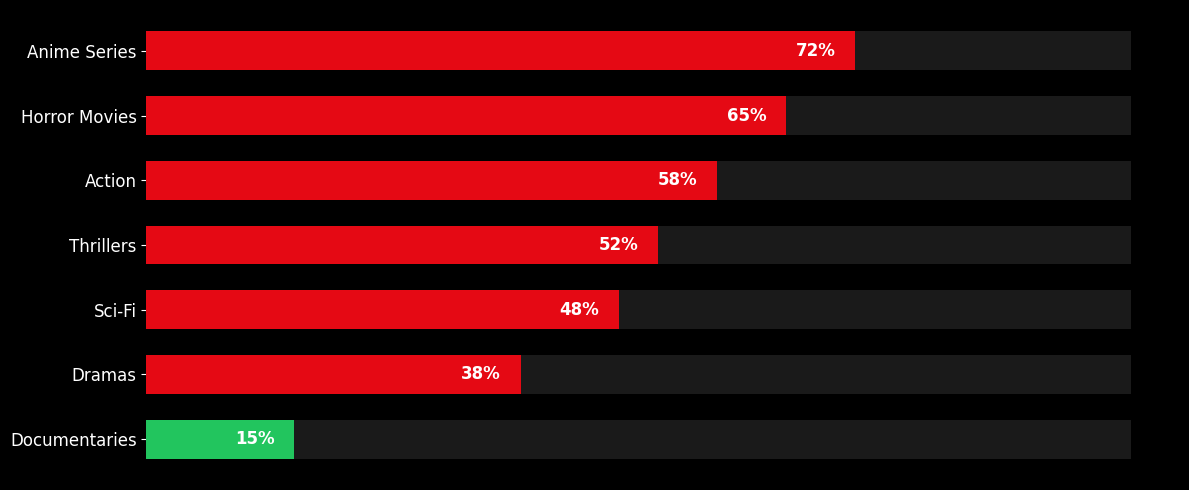

In [45]:
import matplotlib.pyplot as plt

# 1. Configuración visual
plt.style.use('dark_background')
netflix_red = '#E50914'
netflix_green = '#22c55e'

generos = ['Documentaries', 'Dramas', 'Sci-Fi', 'Thrillers', 'Action', 'Horror Movies', 'Anime Series']
tasas = [15, 38, 48, 52, 58, 65, 72]

# 2. Creación del gráfico (Altura ajustada porque ya no hay textos arriba/abajo)
fig, ax = plt.subplots(figsize=(12, 5))

# Colores condicionales (Verde para documentales, rojo para el resto)
colores = [netflix_green if gen == 'Documentaries' else netflix_red for gen in generos]

# Crear las barras principales
bars = ax.barh(generos, tasas, color=colores, height=0.6, zorder=3)

# Crear barras de fondo grises (track oscuro)
ax.barh(generos, [100]*len(generos), color='#1a1a1a', height=0.6, zorder=1)

# 3. Estilizar bordes y limpiar ejes
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([]) # Ocultar eje X

# Valores dentro de las barras
for bar in bars:
    width = bar.get_width()
    ax.text(width - 2, bar.get_y() + bar.get_height()/2, f'{int(width)}%',
            va='center', ha='right', color='white', fontweight='bold', fontsize=12, zorder=4)

ax.tick_params(axis='y', colors='white', labelsize=12)

# Eliminar márgenes sobrantes para que el gráfico ocupe todo el espacio
plt.tight_layout()

plt.show()